# R&D Data Research Platform - Interactive Demo

This notebook demonstrates the full capabilities of the **R&D Data Research Platform** built on BigQuery.

> [!NOTE]
> 🔬 **The documents explored in this notebook are all synthetically generated.** If you would you like to generate your own synthetic documents you can use the Gemini CLI plans as guidance [PLANS](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery/blob/main/gemini-cli-plans/README.md). You can reuse the existing documents by following instruction on the installation guide [INSTALLATION.md](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery/blob/main/INSTALLATION.md) and [README.md](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery/blob/main/README.md) in the [document-analytics-on-bigquery](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery) repository.


## 🎯 Graph Statistics

**8 Node Types:**
- 🧪 **Trial** - 1,200 clinical trials with 768-dim semantic embeddings
- 💊 **Drug** - Pharmaceutical compounds (UMLS CUIs)
- 🩺 **Disorder** - Medical conditions with SNOMED CT hierarchy + embeddings (1,657 disorders)
- 🔬 **MOA** - Mechanisms of Action (536 mechanisms)
- 📋 **TrialCriteria** - Requirements (17 criteria: disease indications, phase, status)
- 🏢 **Company** - Pharmaceutical manufacturers
- 🔢 **Phase** - Trial phases (9: Early Phase 1, Phase 1, 1/2, 2, 2/3, 3, 4, N/A)
- ✅ **Status** - Trial status (8: Recruiting, Active, Completed, Terminated, etc.)

**9 Edge Types:**
- Drug → Disorder (MayTreat): 8,405 relationships
- Disorder → Disorder (IsSubtypeOf): 1,701 SNOMED hierarchy relationships
- Trial → Phase (InPhase): 1,200 relationships
- Trial → Status (HasStatus): 1,200 relationships
- Trial → Criteria (Requires): 2,400 relationships
- Drug → MOA (HasMechanismOfAction)
- Drug → Company (ManufacturedBy): 2 relationships
- Trial → Drug (Uses)
- Trial → Disorder (Treats)

## 📊 Graph Structure (Entity Relationship Diagram)

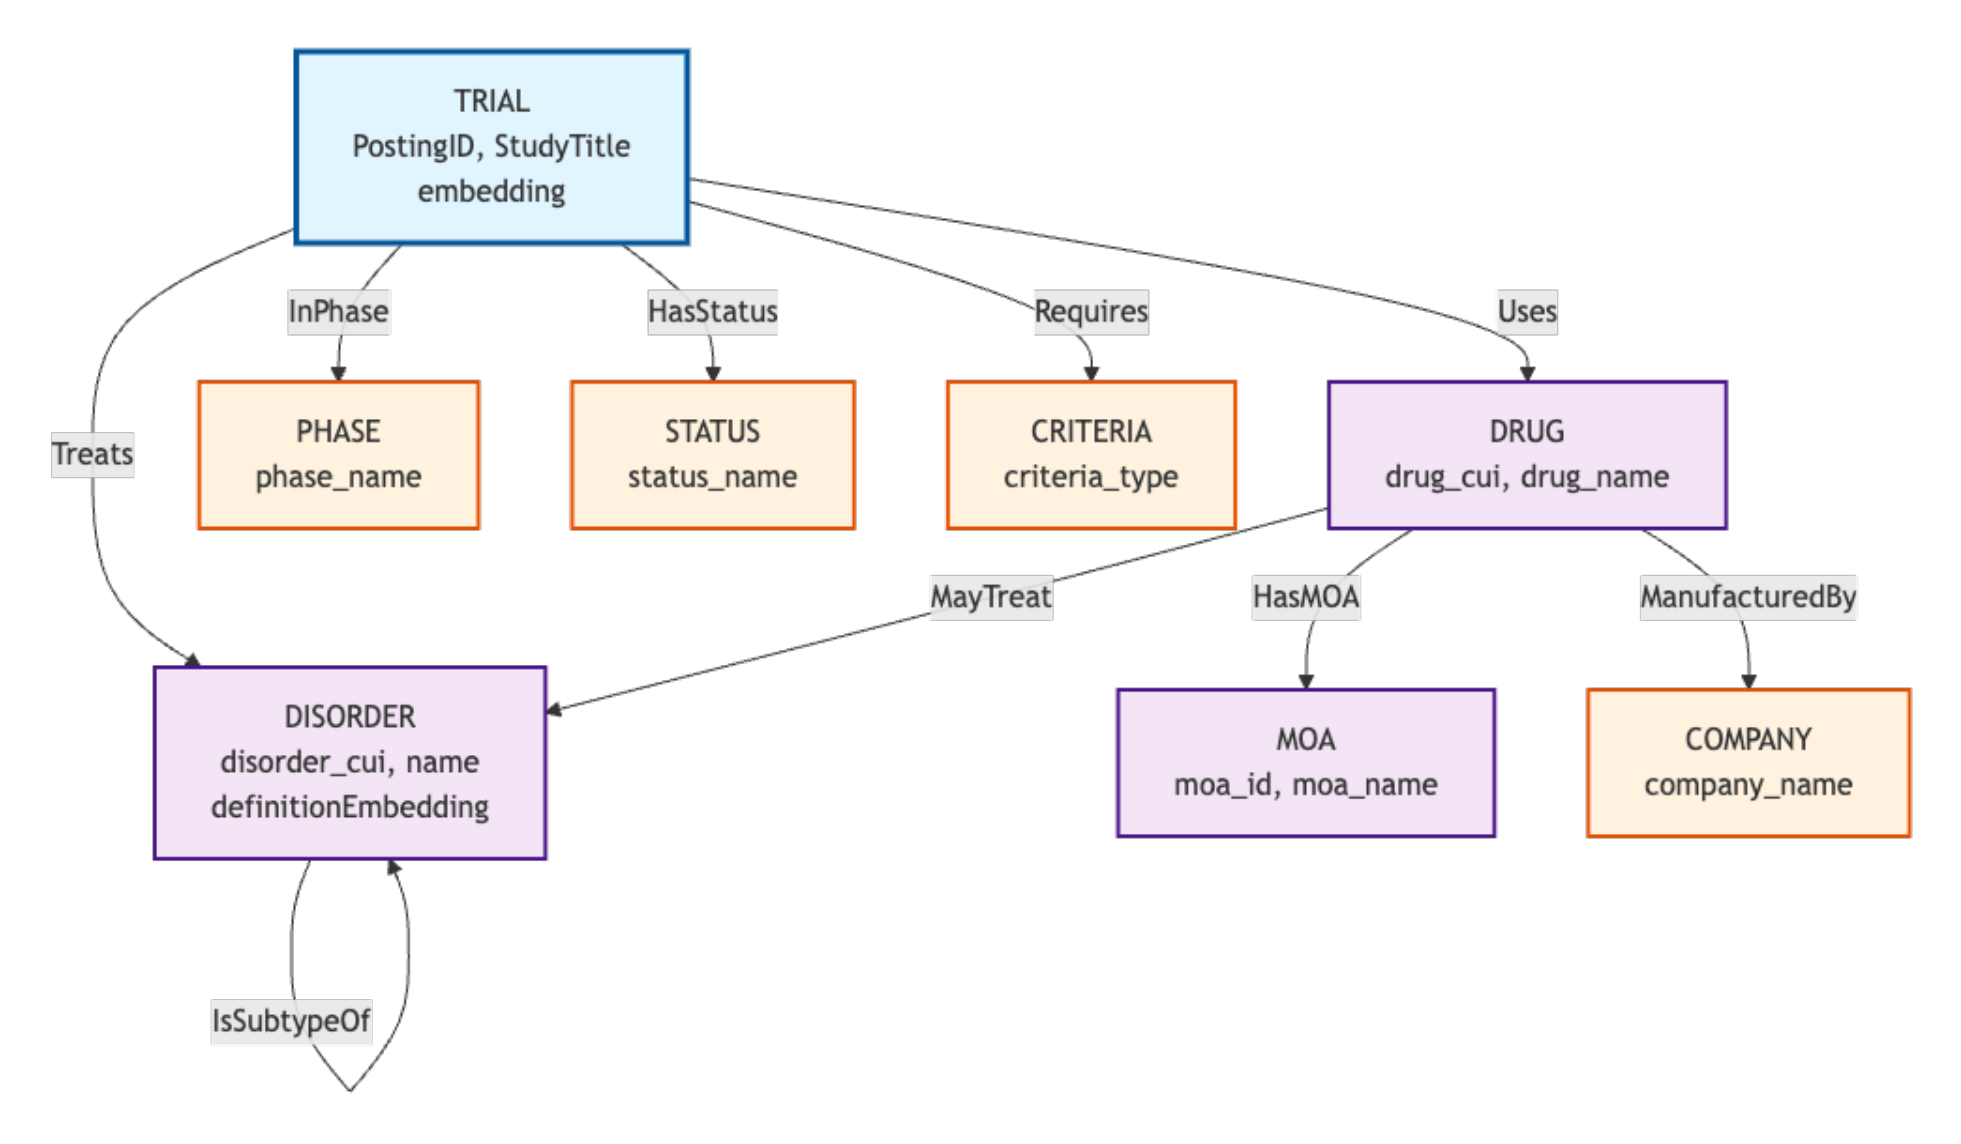



## 🎯 Key Capabilities

1. **Graph Traversal** - Multi-hop pattern matching using GQL (GRAPH_TABLE)
2. **Semantic Search** - Vector similarity using 768-dimensional embeddings
3. **Relational SQL** - Traditional analytics and aggregations
4. **Generative AI** - LLM-powered summaries (Gemini 2.5 Pro)

## 🔬 Example Graph Patterns

**Patient Journey (Symptom → Trial):**
```
"joint pain" --[Vector Search]--> Arthritis --[MayTreat]--> Drug --[Uses]--> Trial
                                                                           |
                                                                           +--[InPhase]--> Phase 3
                                                                           +--[HasStatus]--> Recruiting
```

**Semantic Expansion (SNOMED Hierarchy):**
```
Arthritis --[IsSubtypeOf]--> Rheumatoid Arthritis --[MayTreat]--> Methotrexate
         --[IsSubtypeOf]--> Psoriatic Arthritis --[MayTreat]--> Adalimumab
```

**Drug Pipeline Analysis:**
```
AstraZeneca (Sponsor) --> Trial --[Uses]--> Durvalumab --[HasMOA]--> PD-L1 Inhibitor
                            |                                  |
                            |                                  +--[MayTreat]--> Lung Cancer
                            +--[InPhase]--> Phase 3
```

---

# Part 1: Graph Traversal Queries

These queries demonstrate the power of **graph pattern matching** using BigQuery's GQL syntax with the `GRAPH_TABLE` function.

In [ ]:
# @title Configure Project and Dataset
PROJECT_ID = "[YOUR-PROJECT-ID]" # @param {type:"string"}
DATASET_ID = "[YOUR-DATASET-ID]" # @param {type:"string"}
LOCATION = "us" # @param {type:"string"}


In [ ]:
# Setup
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.api_core.client_info import ClientInfo
from google.cloud import bigquery

# Initialize BigQuery client
custom_info = ClientInfo(user_agent="cloud-solutions/data-to-ai-nb-v2")
client = bigquery.Client(project="<PROJECT_ID>", client_info=custom_info)

# Helper function to run queries


def run_query(query, description=""):
    query = query.replace('<PROJECT_ID>', PROJECT_ID).replace('<DATASET_ID>', DATASET_ID)
    """Helper function to Run a BigQuery query and return results as DataFrame"""
    if description:
        print(f"\n🔍 {description}")
        print("=" * 80)

    df = client.query(query).to_dataframe()
    print(f"\n✅ Returned {len(df)} rows\n")
    return df


# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
sns.set_style("whitegrid")

print("✅ Setup complete!")

## Query 1.1: Phase 3 Recruiting Trials

**Use Case:** Clinical research coordinator looking for active Phase 3 trials

**Graph Pattern:** `Trial -[InPhase]-> Phase3` AND `Trial -[HasStatus]-> Recruiting` AND `Trial -[Uses]-> Drug`

In [ ]:
query_1_1 = """
SELECT
  StudyTitle,
  Sponsor,
  drug_name,
  phase_name,
  status_name
FROM GRAPH_TABLE(
  <DATASET_ID>.DrugGraph
  MATCH
    (t:Trial)-[:InPhase]->(p:Phase),
    (t)-[:HasStatus]->(s:Status),
    (t)-[:Uses]->(d:Drug)
  WHERE p.phase_name = 'PHASE3'
    AND s.status_name = 'RECRUITING'
  RETURN t.StudyTitle, t.Sponsor, d.drug_name, p.phase_name, s.status_name
)
ORDER BY Sponsor, StudyTitle
LIMIT 20
"""

df_1_1 = run_query(query_1_1, "Finding Phase 3 recruiting trials with drugs")
df_1_1

## Query 1.2: Drug Mechanisms for Diabetes Treatment

**Use Case:** Pharmacologist researching treatment options for diabetes

**Graph Pattern:** `Drug -[MayTreat]-> Diabetes` AND `Drug -[HasMechanismOfAction]-> MOA`

In [ ]:
query_1_2 = """
SELECT
  disorder_name,
  drug_name,
  moa_name
FROM GRAPH_TABLE(
  <DATASET_ID>.DrugGraph
  MATCH
    (d:Drug)-[:MayTreat]->(dis:Disorder),
    (d)-[:HasMechanismOfAction]->(m:MechanismOfAction)
  WHERE dis.name LIKE '%Diabetes%'
  RETURN dis.name as disorder_name, d.drug_name, m.moa_name
)
ORDER BY drug_name
LIMIT 10
"""

df_1_2 = run_query(query_1_2, "Finding drug mechanisms for diabetes treatment")
df_1_2

## Query 1.3: Semantic Expansion Using SNOMED Hierarchy

**Use Case:** Patient advocate finding trials for Arthritis AND all its subtypes. This query is designed to semantically expand on the condition 'Arthritis' by finding all its subtypes, it would be much harder to be implemented with pure SQL, and/or it would require vector embeddings to calculate cosine distances.

**Graph Pattern:** `Arthritis <-[IsSubtypeOf]- Subtype <- [MayTreat]- Drug <-[Uses]- Trial`

This demonstrates the power of medical ontologies - finding trials for "Arthritis" also finds trials for "Rheumatoid Arthritis", "Osteoarthritis", etc.

In [ ]:
query_1_3 = """
SELECT
  parent_name,
  child_name,
  drug_name,
  StudyTitle,
  phase_name,
  status_name
FROM GRAPH_TABLE(
  <DATASET_ID>.DrugGraph
  MATCH
    (parent:Disorder)<-[:IsSubtypeOf]-(child:Disorder),
    (d:Drug)-[:MayTreat]->(child),
    (t:Trial)-[:Uses]->(d),
    (t)-[:InPhase]->(p:Phase),
    (t)-[:HasStatus]->(s:Status)
  WHERE parent.name = 'Arthritis'
  RETURN parent.name as parent_name, child.name as child_name,
         d.drug_name, t.StudyTitle, p.phase_name, s.status_name
)
ORDER BY child_name, StudyTitle
LIMIT 20
"""

df_1_3 = run_query(query_1_3, "Semantic expansion: Arthritis and all subtypes")
df_1_3

## Query 1.4: Multi-hop Path - Trial Phase Requirements

**Use Case:** Understanding trial phase requirements for lung cancer treatments

**Graph Pattern:** `Lung Cancer <-[Treats]- Trial -[Uses]-> Drug` AND `Trial -[Requires]-> Criteria`

Shows recruiting lung cancer trials with their phase requirements.

In [ ]:
query_1_4 = """
SELECT
  disorder_name,
  drug_name,
  StudyTitle,
  Sponsor,
  criteria_type,
  criteria_text,
  phase_name,
  status_name
FROM GRAPH_TABLE(
  <DATASET_ID>_demo.DrugGraph
  MATCH
    (dis:Disorder)<-[:Treats]-(t:Trial)-[:Uses]->(d:Drug),
    (t)-[:Requires]->(c:Criteria),
    (t)-[:InPhase]->(p:Phase),
    (t)-[:HasStatus]->(s:Status)
  WHERE dis.name = 'Lung Cancer'
    AND c.criteria_type = 'PHASE_REQUIREMENT'
    AND s.status_name = 'RECRUITING'
  RETURN dis.name as disorder_name, d.drug_name, t.StudyTitle, t.Sponsor,
         c.criteria_type, c.criteria_text, p.phase_name, s.status_name
)
ORDER BY StudyTitle
LIMIT 10
"""

df_1_4 = run_query(query_1_4, "Recruiting lung cancer trials with phase requirements")
df_1_4

## Query 1.5: Sponsor Pipeline Analysis

**Use Case:** Business intelligence - which drugs are in pharma company pipelines?

**Graph Pattern:** `Trial -[Uses]-> Drug` grouped by Sponsor

In [ ]:
query_1_5 = """
SELECT
  Sponsor,
  drug_name,
  COUNT(DISTINCT PostingID) as trial_count,
  ARRAY_AGG(DISTINCT phase_name ORDER BY phase_name) as phases,
  ARRAY_AGG(DISTINCT status_name ORDER BY status_name) as statuses
FROM GRAPH_TABLE(
  <DATASET_ID>.DrugGraph
  MATCH
    (t:Trial)-[:Uses]->(d:Drug),
    (t)-[:InPhase]->(p:Phase),
    (t)-[:HasStatus]->(s:Status)
  WHERE t.Sponsor IS NOT NULL
  RETURN t.Sponsor, d.drug_name, t.PostingID, p.phase_name, s.status_name
)
GROUP BY Sponsor, drug_name
ORDER BY Sponsor, trial_count DESC
LIMIT 20
"""

df_1_5 = run_query(query_1_5, "Company drug pipelines")
df_1_5

## Query 1.6: Trial Landscape by Phase and Status

**Use Case:** Market research - understand the clinical trial landscape

Let's visualize this one!

In [ ]:
query_1_6 = """
SELECT
  phase_name,
  status_name,
  COUNT(*) as trial_count
FROM GRAPH_TABLE(
  <DATASET_ID>.DrugGraph
  MATCH
    (t:Trial)-[:InPhase]->(p:Phase),
    (t)-[:HasStatus]->(s:Status)
  RETURN p.phase_name, s.status_name
)
GROUP BY phase_name, status_name
ORDER BY trial_count DESC
"""

df_1_6 = run_query(query_1_6, "Trial distribution by phase and status")

# Visualize
plt.figure(figsize=(14, 6))

# Top 15 combinations
top_15 = df_1_6.head(15)
top_15["label"] = top_15["phase_name"] + " - " + top_15["status_name"]

plt.barh(top_15["label"], top_15["trial_count"], color="steelblue")
plt.xlabel("Number of Trials", fontsize=12)
plt.title(
    "Clinical Trial Distribution by Phase and Status (Top 15)",
    fontsize=14,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

df_1_6

---

# Part 2: Semantic Search with Vector Embeddings

These queries use **768-dimensional embeddings** from Google's `text-embedding-005` model to find semantically similar content.

## Query 2.1: Find Disorders from Patient Symptoms

**Use Case:** Patient describes symptoms in natural language → system finds matching medical conditions

Patient input: *"joint pain and inflammation with morning stiffness"*


---------------

**Method 1:** Vector similarity search using cosine distance.

Unlike symmetric search (matching a sentence to a sentence), QA involves comparing a very short query (the question) against a corpus of much larger text chunks (the potential answers).

Because the text lengths and structures are fundamentally mismatched, your choice of distance metric depends entirely on the specific architecture of the embedding model you are using to bridge that gap.

COSINE distance is appropriate for Question Answering, since it is an asymetric search use case.

In [ ]:
## This an initial approach. It is full of limitations but still returns interesting results
query_2_1 = """
SELECT
  base.name as disorder_name,
  base.definition,
  distance
FROM VECTOR_SEARCH(
  TABLE `<DATASET_ID>.Disorder`,
  'definitionEmbedding',
  (
    SELECT ml_generate_embedding_result
    FROM ML.GENERATE_EMBEDDING(
      MODEL `<DATASET_ID>.EmbeddingsModel`,
      (SELECT 'joint pain and inflammation with morning stiffness' AS content)
    )
  ),
  top_k => 5,
  distance_type => 'COSINE'
)
ORDER BY distance ASC
"""

df_2_1 = run_query(
    query_2_1, "Finding disorders matching patient symptoms (semantic search)"
)
df_2_1

**Method 2**: Advanced vector similarity search
*   Schema Enforcement: It ensures that every disorder entry strictly follows your id, name, and symptoms structure, similar to your DisorderSymptoms temp table.
*   Task Type: using 'QUESTION_ANSWERING' AS task_type for both the indexing (base table) and the query. For optimal retrieval performance, Google recommends an asymmetric pairing.



In [ ]:
## This an mature approach.
query_2_1 = """
CREATE OR REPLACE TEMP TABLE DisorderSymptoms AS (
    SELECT
      preferred_name AS disorder_name,
      definition AS definition,
      AI.GENERATE(
        (
          'Extract symptoms from these disorders names and definitions: ',
          preferred_name,
          definition),
        connection_id => 'us-central1.llm-connection',
        endpoint => 'gemini-2.5-flash',
        output_schema => 'symptoms ARRAY< STRING>').symptoms
        AS symptoms
    FROM `<DATASET_ID>.Disorder`
  );

  CREATE OR REPLACE TEMP TABLE DisorderEmbeddings AS (
    SELECT disorder_name, definition, symptoms, ml_generate_embedding_result
    FROM
      ML.GENERATE_EMBEDDING(
        MODEL `<DATASET_ID>.EmbeddingsModel`,
        (
          SELECT
            TO_JSON_STRING(t.symptoms) AS content, disorder_name, definition, symptoms
          FROM DisorderSymptoms AS t
        ),
        STRUCT(TRUE AS flatten_json_output, 'QUESTION_ANSWERING' AS task_type))
  )
;

SELECT base.disorder_name, base.definition, base.symptoms, distance
FROM
  VECTOR_SEARCH(
    TABLE DisorderEmbeddings,
    'ml_generate_embedding_result',
    (
      SELECT ml_generate_embedding_result
      FROM
        ML.GENERATE_EMBEDDING(
          MODEL `<DATASET_ID>.EmbeddingsModel`,
          (
            SELECT
              'joint pain and inflammation with morning stiffness' AS content
          ),
          STRUCT(
            TRUE AS flatten_json_output, 'QUESTION_ANSWERING' AS task_type))
    ),
    top_k => 5,
    distance_type => 'COSINE')
ORDER BY distance ASC;
"""

df_2_1 = run_query(
    query_2_1, "Finding disorders matching patient symptoms (semantic search)"
)
df_2_1

**Method 3**: LLM-based text search
LLM-based filtering and ranking. You are essentially using the LLM as a "Zero-Shot Classifier" to decide which rows match and how well they rank.
*   Breaking down into sub search queries: It ensures that every sympthom will be scaned in the DisorderSymptoms temp table.
*   AI.GENERATE_BOOL and AI.GENERATE_INT for every row in your table is what we call "LLM-on-the-scan." It is extremely accurate because the model "reads" every definition, but it is linearly expensive and slow.

In [ ]:
query_2_1 = """
CREATE OR REPLACE TEMP TABLE DisorderSymptoms AS (
  SELECT
    preferred_name AS disorder_name,
    definition AS definition,
    AI.GENERATE(
      (
        'Extract unique symptoms to be looked in a search query from these disorders names and definitions: ',
        preferred_name,
        definition),
      connection_id => 'us-central1.llm-connection',
      endpoint => 'gemini-2.5-flash',
      output_schema => 'symptoms ARRAY< STRING>').symptoms
      AS symptoms
  FROM `<DATASET_ID>.Disorder`
);


SELECT
  disorder_name,
  definition,
  symptoms
FROM DisorderSymptoms AS t
WHERE
  AI.GENERATE_BOOL(
    ('Does this disorder presents any one of these symptoms: joint pain and inflammation with morning stiffness', TO_JSON_STRING(t)),
    connection_id => 'us-central1.llm-connection',
    endpoint => 'gemini-2.5-flash').result = true
AND
AI.GENERATE_INT(
    ('Rank this disorder based on the previously matched symptoms to this search query: joint pain and inflammation with morning stiffness. Output must be between 0 and 10. Highly related disorders should have a higher rank.', TO_JSON_STRING(t)),
    connection_id => 'us-central1.llm-connection',
    endpoint => 'gemini-2.5-flash').result > 7
"""

df_2_1 = run_query(
    query_2_1,
    "Finding disorders matching patient symptoms (Full text search powered by Gemini)",
)
df_2_1

## Query 2.2: Find Trials by Research Interest

**Use Case:** Researcher looking for trials matching a specific research area

**Method:** Vector search on trial semantic text embeddings

Research query: *"cardiovascular outcomes in type 2 diabetes patients"*

In [ ]:
query_2_2 = """
SELECT
  base.StudyTitle,
  base.Sponsor,
  base.Phase,
  base.Trial_Status,
  LEFT(base.semantic_text, 200) as trial_summary,
  distance
FROM VECTOR_SEARCH(
  TABLE `<DATASET_ID>.Trials`,
  'embedding',
  (
    SELECT ml_generate_embedding_result
    FROM ML.GENERATE_EMBEDDING(
      MODEL `<DATASET_ID>.EmbeddingsModel`,
      (SELECT 'cardiovascular outcomes in type 2 diabetes patients' AS content),
      STRUCT(TRUE AS flatten_json_output, 'QUESTION_ANSWERING' as task_type)
    )
  ),
  top_k => 10,
  distance_type => 'COSINE'
)
ORDER BY distance ASC
"""

df_2_2 = run_query(
    query_2_2, "Finding trials matching research interest (semantic search)"
)
df_2_2

## Query 2.3: Hybrid Search - Semantic + Graph

**Use Case:** Find recruiting trials for conditions semantically similar to patient symptoms

**Method:**
1. Vector search to find similar disorders
2. Graph traversal to find recruiting trials treating those disorders

Patient symptoms: *"chronic respiratory disease with breathing difficulty"*

In [ ]:
query_2_3 = """
WITH similar_disorders AS (
  SELECT base.name, base.disorder_cui, distance
  FROM VECTOR_SEARCH(
    TABLE `<DATASET_ID>.Disorder`,
    'definitionEmbedding',
    (
      SELECT ml_generate_embedding_result
      FROM ML.GENERATE_EMBEDDING(
        MODEL `<DATASET_ID>.EmbeddingsModel`,
        (SELECT 'chronic respiratory disease with breathing difficulty' AS content)
      )
    ),
    top_k => 3,
    distance_type => 'COSINE'
  )
  WHERE distance < 0.5
)
SELECT
  sd.name as matched_disorder,
  sd.distance as semantic_distance,
  StudyTitle,
  Sponsor,
  drug_name,
  phase_name,
  status_name
FROM similar_disorders sd
JOIN GRAPH_TABLE(
  <DATASET_ID>.DrugGraph
  MATCH
    (dis:Disorder)<-[:Treats]-(t:Trial)-[:Uses]->(d:Drug),
    (t)-[:InPhase]->(p:Phase),
    (t)-[:HasStatus]->(s:Status)
  WHERE s.status_name = 'RECRUITING'
  RETURN dis.disorder_cui, t.StudyTitle, t.Sponsor, d.drug_name, p.phase_name, s.status_name
) AS graph_results
ON sd.disorder_cui = graph_results.disorder_cui
ORDER BY sd.distance, StudyTitle
LIMIT 15
"""

df_2_3 = run_query(query_2_3, "Hybrid semantic + graph search for recruiting trials")
df_2_3

---

# Part 3: Relational SQL Analytics

Traditional SQL queries for aggregations and statistical analysis.

## Query 3.1: Trial Portfolio by Sponsor

**Use Case:** Competitive intelligence on pharmaceutical companies

In [ ]:
query_3_1 = """
SELECT
  Sponsor,
  COUNT(DISTINCT PostingID) as total_trials,
  COUNT(DISTINCT CASE WHEN Phase = 'PHASE3' THEN PostingID END) as phase3_trials,
  COUNT(DISTINCT CASE WHEN Trial_Status = 'RECRUITING' THEN PostingID END) as recruiting_trials,
  COUNT(DISTINCT CASE WHEN Trial_Status = 'COMPLETED' THEN PostingID END) as completed_trials,
  ROUND(AVG(char_count), 0) as avg_protocol_length
FROM `<DATASET_ID>.Trials`
WHERE Sponsor IS NOT NULL
GROUP BY Sponsor
ORDER BY total_trials DESC
LIMIT 10
"""

df_3_1 = run_query(query_3_1, "Trial portfolio analysis by sponsor")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total trials by sponsor
axes[0].barh(df_3_1["Sponsor"], df_3_1["total_trials"], color="steelblue")
axes[0].set_xlabel("Total Trials", fontsize=12)
axes[0].set_title("Total Trials by Sponsor", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()

# Phase 3 vs recruiting breakdown
x = range(len(df_3_1))
width = 0.35
axes[1].barh(
    [i - width / 2 for i in x],
    df_3_1["phase3_trials"],
    width,
    label="Phase 3",
    color="coral",
)
axes[1].barh(
    [i + width / 2 for i in x],
    df_3_1["recruiting_trials"],
    width,
    label="Recruiting",
    color="lightgreen",
)
axes[1].set_yticks(x)
axes[1].set_yticklabels(df_3_1["Sponsor"])
axes[1].set_xlabel("Number of Trials", fontsize=12)
axes[1].set_title("Phase 3 vs Recruiting Trials", fontsize=13, fontweight="bold")
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

df_3_1

## Query 3.2: Disorder Coverage Analysis

**Use Case:** Identify which disorders have the most research vs. underserved conditions

In [ ]:
query_3_2 = """
SELECT
  d.name as disorder_name,
  d.definition,
  COUNT(DISTINCT dd.drug_cui) as drugs_researched,
  COUNT(DISTINCT td.posting_id) as active_trials,
  ARRAY_AGG(DISTINCT dr.drug_name IGNORE NULLS ORDER BY dr.drug_name LIMIT 5) as sample_drugs
FROM `<DATASET_ID>.Disorder` d
LEFT JOIN `<DATASET_ID>.DrugDisorder` dd ON d.disorder_cui = dd.disorder_cui
LEFT JOIN `<DATASET_ID>.Drug` dr ON dd.drug_cui = dr.drug_cui
LEFT JOIN `<DATASET_ID>.TrialDisorder` td ON d.disorder_cui = td.disorder_cui
GROUP BY d.disorder_cui, d.name, d.definition
HAVING COUNT(DISTINCT td.posting_id) > 0
ORDER BY active_trials DESC, drugs_researched DESC
LIMIT 20
"""

df_3_2 = run_query(query_3_2, "Disorder research coverage")
df_3_2

## Query 3.3: Drug Utilization Across Trials

**Use Case:** Which drugs are most studied? Identify repurposing opportunities

In [ ]:
query_3_3 = """
SELECT
  d.drug_name,
  COUNT(DISTINCT td.posting_id) as trial_count,
  COUNT(DISTINCT dd.disorder_cui) as disorders_targeted,
  COUNT(DISTINCT dm.moa_id) as mechanisms_of_action,
  ARRAY_AGG(DISTINCT dis.name IGNORE NULLS ORDER BY dis.name LIMIT 3) as sample_disorders,
  ARRAY_AGG(DISTINCT m.moa_name IGNORE NULLS ORDER BY m.moa_name LIMIT 2) as sample_moas
FROM `<DATASET_ID>.Drug` d
LEFT JOIN `<DATASET_ID>.TrialDrug` td ON d.drug_cui = td.drug_cui
LEFT JOIN `<DATASET_ID>.DrugDisorder` dd ON d.drug_cui = dd.drug_cui
LEFT JOIN `<DATASET_ID>.Disorder` dis ON dd.disorder_cui = dis.disorder_cui
LEFT JOIN `<DATASET_ID>.DrugMOA` dm ON d.drug_cui = dm.drug_cui
LEFT JOIN `<DATASET_ID>.MOA` m ON dm.moa_id = m.moa_id
GROUP BY d.drug_cui, d.drug_name
HAVING trial_count > 0
ORDER BY trial_count DESC
LIMIT 20
"""

df_3_3 = run_query(query_3_3, "Drug utilization and repurposing analysis")
df_3_3

## Query 3.4: Phase Progression Analysis

**Use Case:** Understanding trial success rates and phase distribution

In [ ]:
query_3_4 = """
SELECT
  p.phase_name,
  p.phase_description,
  COUNT(*) as trial_count,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage,
  COUNT(CASE WHEN s.status_name = 'COMPLETED' THEN 1 END) as completed,
  COUNT(CASE WHEN s.status_name = 'RECRUITING' THEN 1 END) as recruiting,
  COUNT(CASE WHEN s.status_name = 'TERMINATED' THEN 1 END) as terminated
FROM `<DATASET_ID>.Phase` p
JOIN `<DATASET_ID>.TrialPhase` tp ON p.phase_id = tp.phase_id
JOIN `<DATASET_ID>.TrialStatus` ts ON tp.posting_id = ts.posting_id
JOIN `<DATASET_ID>.Status` s ON ts.status_id = s.status_id
GROUP BY p.phase_id, p.phase_name, p.phase_description
ORDER BY trial_count DESC
"""

df_3_4 = run_query(query_3_4, "Phase progression and success analysis")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phase distribution pie chart
axes[0].pie(
    df_3_4["trial_count"], labels=df_3_4["phase_name"], autopct="%1.1f%%", startangle=90
)
axes[0].set_title("Trial Distribution by Phase", fontsize=13, fontweight="bold")

# Status breakdown by phase
df_status = df_3_4[["phase_name", "completed", "recruiting", "terminated"]].set_index(
    "phase_name"
)
df_status.plot(
    kind="bar", stacked=True, ax=axes[1], color=["#2ecc71", "#3498db", "#e74c3c"]
)
axes[1].set_title("Trial Status by Phase", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Phase", fontsize=11)
axes[1].set_ylabel("Number of Trials", fontsize=11)
axes[1].legend(title="Status")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

df_3_4

---

# Part 4: Generative AI with LLMs

These queries use **Gemini 2.5 Pro** to generate patient-friendly content and insights.

## Query 4.1: Generate Patient-Friendly Trial Summaries

**Use Case:** Transform technical trial protocols into easy-to-understand explanations

**Method:** LLM takes trial metadata (drugs, disorders, mechanisms, phase, status) and generates simple summaries

In [ ]:
query_4_1 = '''
WITH trial_context AS (
  SELECT
    t.PostingID,
    t.StudyTitle,
    t.Sponsor,
    p.phase_name,
    s.status_name,
    STRING_AGG(DISTINCT d.drug_name, ', ') as drugs,
    STRING_AGG(DISTINCT dis.name, ', ') as disorders,
    STRING_AGG(DISTINCT m.moa_name, ', ') as mechanisms
  FROM `<DATASET_ID>.Trials` t
  JOIN `<DATASET_ID>.TrialPhase` tp ON t.PostingID = tp.posting_id
  JOIN `<DATASET_ID>.Phase` p ON tp.phase_id = p.phase_id
  JOIN `<DATASET_ID>.TrialStatus` ts ON t.PostingID = ts.posting_id
  JOIN `<DATASET_ID>.Status` s ON ts.status_id = s.status_id
  LEFT JOIN `<DATASET_ID>.TrialDrug` td ON t.PostingID = td.posting_id
  LEFT JOIN `<DATASET_ID>.Drug` d ON td.drug_cui = d.drug_cui
  LEFT JOIN `<DATASET_ID>.TrialDisorder` tdi ON t.PostingID = tdi.posting_id
  LEFT JOIN `<DATASET_ID>.Disorder` dis ON tdi.disorder_cui = dis.disorder_cui
  LEFT JOIN `<DATASET_ID>.DrugMOA` dm ON d.drug_cui = dm.drug_cui
  LEFT JOIN `<DATASET_ID>.MOA` m ON dm.moa_id = m.moa_id
  WHERE s.status_name = 'RECRUITING'
    AND p.phase_name IN ('PHASE2', 'PHASE3')
  GROUP BY t.PostingID, t.StudyTitle, t.Sponsor, p.phase_name, s.status_name
  LIMIT 3
),
prompts AS (
  SELECT
    PostingID,
    StudyTitle,
    FORMAT("""Create a 2-3 sentence patient-friendly summary of this clinical trial:

Trial: %s
Sponsor: %s
Phase: %s
Status: %s
Drugs being tested: %s
Conditions treated: %s
Drug mechanisms: %s

Write the summary in simple, non-technical language that a patient could easily understand. Focus on what the trial is testing and who it might help.""",
      StudyTitle, Sponsor, phase_name, status_name,
      COALESCE(drugs, 'Not specified'),
      COALESCE(disorders, 'Not specified'),
      COALESCE(mechanisms, 'Not specified')
    ) as prompt
  FROM trial_context
)
SELECT
  StudyTitle,
  ml_generate_text_llm_result as patient_friendly_summary
FROM ML.GENERATE_TEXT(
  MODEL `<DATASET_ID>.LLMModel`,
  TABLE prompts,
  STRUCT(
    TRUE AS flatten_json_output,
    8192 AS max_output_tokens,
    0.2 AS temperature
  )
)
'''

df_4_1 = run_query(query_4_1, "Generating patient-friendly trial summaries with LLM")
df_4_1

## Query 4.2: Generate Eligibility Guidance

**Use Case:** Help patients understand if they might qualify for a trial

**Method:** LLM analyzes inclusion/exclusion criteria and creates personalized guidance

In [ ]:
query_4_2 = '''
WITH trial_criteria AS (
  SELECT
    t.PostingID,
    t.StudyTitle,
    dis.name as disorder,
    STRING_AGG(
      CASE WHEN tc.criteria_type = 'Inclusion' THEN tc.criteria_text END,
      ' | '
    ) as inclusion_criteria,
    STRING_AGG(
      CASE WHEN tc.criteria_type = 'Exclusion' THEN tc.criteria_text END,
      ' | '
    ) as exclusion_criteria
  FROM `<DATASET_ID>.Trials` t
  JOIN `<DATASET_ID>.TrialStatus` ts ON t.PostingID = ts.posting_id
  JOIN `<DATASET_ID>.Status` s ON ts.status_id = s.status_id
  JOIN `<DATASET_ID>.TrialDisorder` td ON t.PostingID = td.posting_id
  JOIN `<DATASET_ID>.Disorder` dis ON td.disorder_cui = dis.disorder_cui
  LEFT JOIN `<DATASET_ID>.TrialRequires` tr ON t.PostingID = tr.posting_id
  LEFT JOIN `<DATASET_ID>.TrialCriteria` tc ON tr.criteria_id = tc.criteria_id
  WHERE s.status_name = 'RECRUITING'
    AND dis.name LIKE '%Diabetes%'
  GROUP BY t.PostingID, t.StudyTitle, dis.name
  LIMIT 5
),
prompts AS (
  SELECT
    PostingID,
    StudyTitle,
    FORMAT("""Based on this clinical trial information, explain in patient-friendly language who would be a good candidate:

Trial: %s
Condition: %s

Key requirements to participate:
%s

You should NOT participate if:
%s

Provide a clear, encouraging explanation of who this trial is designed for.""",
      StudyTitle, disorder,
      COALESCE(inclusion_criteria, 'Not specified'),
      COALESCE(exclusion_criteria, 'Not specified')
    ) as prompt
  FROM trial_criteria
)
SELECT
  StudyTitle,
  ml_generate_text_llm_result as eligibility_guidance
FROM ML.GENERATE_TEXT(
  MODEL `<DATASET_ID>.LLMModel`,
  TABLE prompts,
  STRUCT(
    TRUE AS flatten_json_output,
    8192 AS max_output_tokens,
    0.3 AS temperature
  )
)
'''

df_4_2 = run_query(query_4_2, "Generating eligibility guidance with LLM")
df_4_2

---

# Part 5: Multi-Modal Combined Queries

These queries combine **all 4 capabilities** to create powerful end-to-end workflows.

## Query 5.1: Complete Patient Journey

**Use Case:** Patient describes symptoms → System finds trials → Generates personalized recommendations

**Workflow:**
1. **Semantic Search** - Find disorders matching "chronic joint pain and stiffness"
2. **Graph Traversal** - Find recruiting Phase 2/3 trials treating those disorders
3. **Relational SQL** - Get exclusion criteria
4. **LLM Generation** - Create personalized recommendations

This is the **complete 4-pillar platform** in action!

In [ ]:
query_5_1 = '''
WITH
-- Step 1: Semantic Search - Find disorders matching patient symptoms
similar_disorders AS (
  SELECT base.name, base.disorder_cui, base.definition, distance
  FROM VECTOR_SEARCH(
    TABLE `<DATASET_ID>.Disorder`,
    'definitionEmbedding',
    (
      SELECT ml_generate_embedding_result
      FROM ML.GENERATE_EMBEDDING(
        MODEL `<DATASET_ID>.EmbeddingsModel`,
        (SELECT 'chronic joint pain and stiffness in hands and knees' AS content)
      )
    ),
    top_k => 3,
    distance_type => 'COSINE'
  )
  WHERE distance < 0.5
),
-- Step 2: Graph Traversal - Find relevant recruiting trials
relevant_trials AS (
  SELECT
    sd.name as matched_disorder,
    sd.definition,
    StudyTitle,
    Sponsor,
    PostingID,
    drug_name,
    phase_name,
    status_name
  FROM similar_disorders sd
  JOIN GRAPH_TABLE(
    <DATASET_ID>.DrugGraph
    MATCH
      (dis:Disorder)<-[:Treats]-(t:Trial)-[:Uses]->(d:Drug),
      (t)-[:InPhase]->(p:Phase),
      (t)-[:HasStatus]->(s:Status)
    WHERE s.status_name = 'RECRUITING'
      AND p.phase_name IN ('PHASE2', 'PHASE3')
    RETURN dis.disorder_cui, dis.name, t.PostingID, t.StudyTitle, t.Sponsor,
           d.drug_name, p.phase_name, s.status_name
  ) AS graph_results
  ON sd.disorder_cui = graph_results.disorder_cui
  LIMIT 5
),
-- Step 3: Relational SQL - Get exclusion criteria
trial_details AS (
  SELECT
    rt.*,
    STRING_AGG(tc.criteria_text, ' | ') as exclusion_criteria
  FROM relevant_trials rt
  LEFT JOIN `<DATASET_ID>.TrialRequires` tr ON rt.PostingID = tr.posting_id
  LEFT JOIN `<DATASET_ID>.TrialCriteria` tc
    ON tr.criteria_id = tc.criteria_id AND tc.criteria_type = 'Exclusion'
  GROUP BY
    rt.matched_disorder, rt.definition, rt.StudyTitle, rt.Sponsor,
    rt.PostingID, rt.drug_name, rt.phase_name, rt.status_name
),
-- Step 4: LLM Generation - Create personalized recommendations
prompts AS (
  SELECT
    PostingID,
    StudyTitle,
    FORMAT("""Based on a patient's symptoms of "chronic joint pain and stiffness in hands and knees",
this trial was matched because it treats: %s (%s)

Trial Information:
- Study: %s
- Sponsor: %s
- Drug: %s
- Phase: %s
- Status: %s
- Exclusions: %s

Write a brief, empathetic recommendation explaining:
1. Why this trial might be relevant for the patient
2. Key things to know about participation
3. Next steps the patient should take""",
      matched_disorder,
      COALESCE(definition, 'No definition available'),
      StudyTitle,
      Sponsor,
      COALESCE(drug_name, 'Not specified'),
      phase_name,
      status_name,
      COALESCE(exclusion_criteria, 'Not specified')
    ) as prompt
  FROM trial_details
)
SELECT
  StudyTitle,
  ml_generate_text_llm_result as personalized_recommendation
FROM ML.GENERATE_TEXT(
  MODEL `<DATASET_ID>.LLMModel`,
  TABLE prompts,
  STRUCT(
    TRUE AS flatten_json_output,
    8192 AS max_output_tokens,
    0.4 AS temperature
  )
)
'''

df_5_1 = run_query(
    query_5_1, "Complete patient journey: Symptoms → Semantic Search → Graph → LLM"
)
df_5_1

## Query 5.2: Drug Repurposing Analysis

**Use Case:** Identify drugs being tested for multiple conditions and analyze repurposing opportunities

**Workflow:**
1. **Graph Analysis** - Find drugs targeting 3+ different disorders
2. **Statistical Analysis** - Aggregate trial counts, phases, mechanisms
3. **LLM Interpretation** - Generate insights on repurposing potential

In [ ]:
query_5_2 = '''
WITH drug_versatility AS (
  SELECT
    drug_name,
    COUNT(DISTINCT disorder_cui) as disorder_count,
    ARRAY_AGG(DISTINCT disorder_name IGNORE NULLS ORDER BY disorder_name) as disorders,
    ARRAY_AGG(DISTINCT moa_name IGNORE NULLS ORDER BY moa_name) as mechanisms,
    COUNT(DISTINCT PostingID) as trial_count,
    ARRAY_AGG(DISTINCT phase_name IGNORE NULLS ORDER BY phase_name) as phases
  FROM GRAPH_TABLE(
    <DATASET_ID>.DrugGraph
    MATCH
      (d:Drug)-[:MayTreat]->(dis:Disorder),
      (d)-[:HasMechanismOfAction]->(m:MechanismOfAction),
      (d)<-[:Uses]-(t:Trial),
      (t)-[:InPhase]->(p:Phase)
    RETURN d.drug_name, dis.disorder_cui, dis.name as disorder_name,
           m.moa_name, t.PostingID, p.phase_name
  )
  GROUP BY drug_name
  HAVING disorder_count >= 3
  ORDER BY disorder_count DESC, trial_count DESC
  LIMIT 5
),
prompts AS (
  SELECT
    drug_name,
    FORMAT("""Analyze this drug's therapeutic potential based on clinical trial data:

Drug: %s
Number of different conditions targeted: %d
Conditions: %s
Mechanisms of action: %s
Total trials: %d
Trial phases: %s

Provide a brief analysis of:
1. Why this drug shows promise for treating multiple conditions
2. Potential repurposing opportunities
3. Research trends based on the phase distribution""",
      drug_name,
      disorder_count,
      ARRAY_TO_STRING(disorders, ', '),
      ARRAY_TO_STRING(mechanisms, ', '),
      trial_count,
      ARRAY_TO_STRING(phases, ', ')
    ) as prompt
  FROM drug_versatility
)
SELECT
  drug_name,
  ml_generate_text_llm_result as repurposing_analysis
FROM ML.GENERATE_TEXT(
  MODEL `<DATASET_ID>.LLMModel`,
  TABLE prompts,
  STRUCT(
    TRUE AS flatten_json_output,
    8192 AS max_output_tokens,
    0.5 AS temperature
  )
)
'''

df_5_2 = run_query(
    query_5_2, "Drug repurposing analysis using graph + statistical + LLM analysis"
)
df_5_2

---

# Conclusion

The **Clinical Trials Knowledge Graph** platform demonstrates how **BigQuery Property Graphs** and **Gemini AI** transform clinical development decision-making:

## 💡 From Data to Decisions

Traditional clinical trial analysis requires:
- Manual literature reviews (weeks)
- Siloed data systems (SQL databases, graph databases, vector databases)
- Expert interpretation of complex medical terminology

This platform enables:
- **Instant Insights**: Query 1,200 trials, 8,400 relationships, and 1,700 SNOMED hierarchies in seconds
- **Unified Platform**: One query combines graph patterns, semantic search, and LLM generation
- **Accessible Analysis**: Gemini translates medical complexity into patient-friendly language

## 🎯 Patient Segmentation at Scale

The platform supports Pfizer's core goals:

1. **Faster Time to Insights**  
   Multi-modal queries (Query 5.1) find relevant trials, match patient symptoms, and generate personalized recommendations in a single execution

2. **Increased PTS of Clinical Development Strategies**  
   Graph traversal queries (Query 1.3, 1.4) identify patient subgroups through SNOMED hierarchies and trial criteria, enabling evidence-based trial design

3. **Improved Treatment Outcomes**  
   Semantic matching (Query 2.3) expands patient populations by finding trials for related conditions, increasing addressable populations while maintaining clinical relevance

4. **Generalizable Model**  
   The same graph schema and query patterns work across therapeutic areas—change the disorder name from "Arthritis" to "Diabetes" to "Lung Cancer" without rewriting analysis logic

## 🚀 Next Steps

Extend this foundation with:
- **Real-World Data Integration**: Connect EHR data, insurance claims, and patient registries to the graph
- **Temporal Analysis**: Add trial timelines, patient progression, and longitudinal outcomes as new node/edge types
- **Predictive Models**: Use Gemini to predict trial success rates based on historical graph patterns
- **Patient Matching Algorithms**: Build automated trial recommendation systems using the semantic search + graph traversal patterns demonstrated in Query 5.1

The platform's value scales with data—each new trial, disorder, or patient record strengthens the graph's analytical power while maintaining query simplicity through BigQuery's unified analytics engine.